In [1]:
import numpy as np
import matplotlib.pyplot as plt
from unyt import yr, Myr, Msun, angstrom
from synthesizer.parametric import SFH
from unyt import unyt_quantity
from synthesizer.parametric import SFH, Stars, ZDist
from synthesizer.grid import Grid
import h5py

In [2]:
grid = Grid('test_grid')

print(grid)



+-----------------------------------------------------------------------------------------------------+
|                                                GRID                                                 |
+-----------------------------+-----------------------------------------------------------------------+
| Attribute                   | Value                                                                 |
+-----------------------------+-----------------------------------------------------------------------+
| grid_dir                    | '/Users/sw376/Dropbox/Research/data/synthesizer/grids'                |
+-----------------------------+-----------------------------------------------------------------------+
| grid_name                   | 'test_grid'                                                           |
+-----------------------------+-----------------------------------------------------------------------+
| grid_ext                    | 'hdf5'                          

## define the star formation history

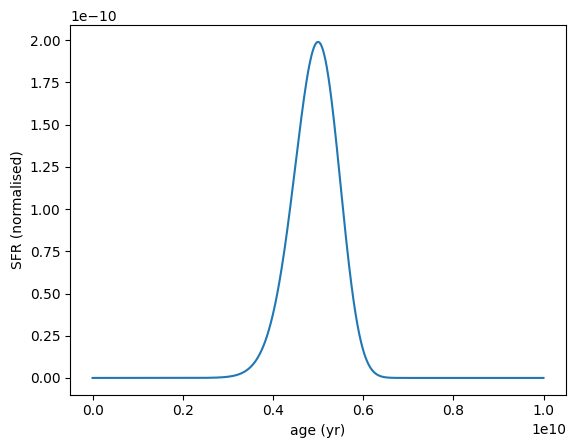

In [3]:

sfh = SFH.LogNormal(tau=0.1, peak_age=5e9 * yr, max_age=1E10*yr)

sfh.plot_sfh(t_range=(0, 1E10))


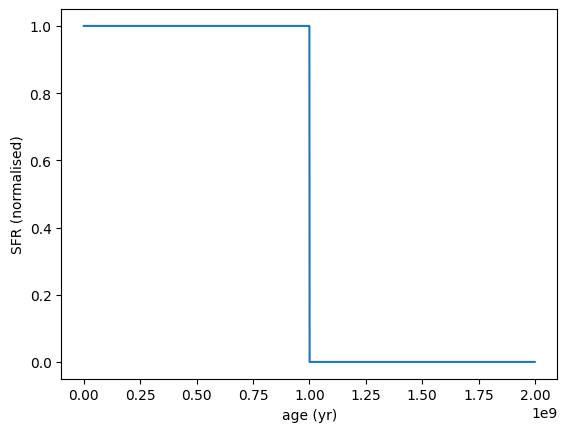

In [4]:
# Define constant star formation history
sfh = SFH.Constant(max_age=1E9*yr)
sfh.plot_sfh(t_range=(0, 2E9))

# Define a delta function for metallicity
metal_dist = ZDist.DeltaConstant(log10metallicity=-2.5)

/Users/sw376/Dropbox/Research/projects/synthpop/venv/lib/python3.10/site-packages/unyt/array.py:1900: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


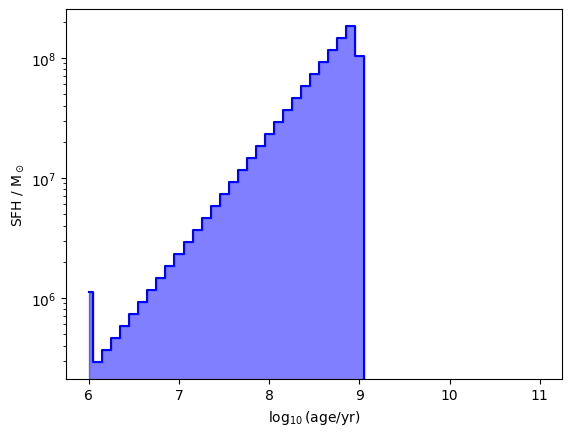

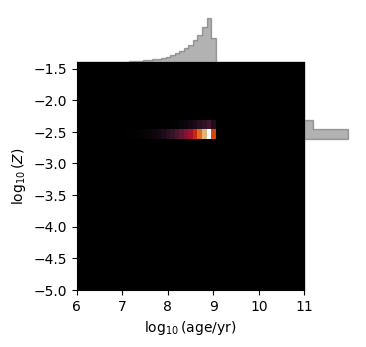

1129462.7052626703
292446.5960662913
--- Initial mass:
9.00
9.00
--- Surviving mass:
8.81


In [5]:


# Create the Stars object
stars = Stars(
    grid.log10ages,
    grid.metallicities,
    sf_hist=sfh,
    metal_dist=metal_dist,
    initial_mass=10**9 * Msun,
)

stars.plot_sfh()
stars.plot_sfzh()

print(stars.sf_hist[0])
print(stars.sf_hist[1])


print('--- Initial mass:')
print(f'{np.log10(stars.initial_mass.to("Msun").value):.2f}')
print(f'{np.log10(np.sum(stars.sf_hist)):.2f}')
print('--- Surviving mass:')
print(f'{np.log10(stars.calculate_surviving_mass(grid=grid).to("Msun").value):.2f}')

In [6]:
# print(f'{np.log10(stars.calculate_initial_mass_at_age(0.0*Myr).to("Msun").value):.2f}')
# print(f'{np.log10(stars.calculate_initial_mass_at_age(500*Myr).to("Msun").value):.2f}')

In [7]:
# Create the Stars object
stars = Stars(
    grid.log10ages,
    grid.metallicities,
    sf_hist=sfh,
    metal_dist=metal_dist,
)

print('--- Initial mass:')
print(f'{np.log10(stars.initial_mass.to("Msun").value):.2f}')
print(f'{np.log10(np.sum(stars.sf_hist)):.2f}')
print('--- Surviving mass:')
print(f'{np.log10(stars.calculate_surviving_mass(grid=grid).to("Msun").value):.2f}')

--- Initial mass:
9.00
9.00
--- Surviving mass:
8.81


In [8]:
# Create the Stars object
stars = Stars(
    grid.log10ages,
    grid.metallicities,
    sf_hist=sfh,
    metal_dist=metal_dist,
    surviving_mass=10**9 * Msun,
    grid=grid,
)

print('--- Initial mass:')
print(f'{np.log10(stars.initial_mass.to("Msun").value):.2f}')
print(f'{np.log10(np.sum(stars.sf_hist)):.2f}')
print('--- Surviving mass:')
print(f'{np.log10(stars.calculate_surviving_mass(grid=grid).to("Msun").value):.2f}')


--- Initial mass:
9.20
9.20
--- Surviving mass:
9.00


#### Galaxy viewed at different age

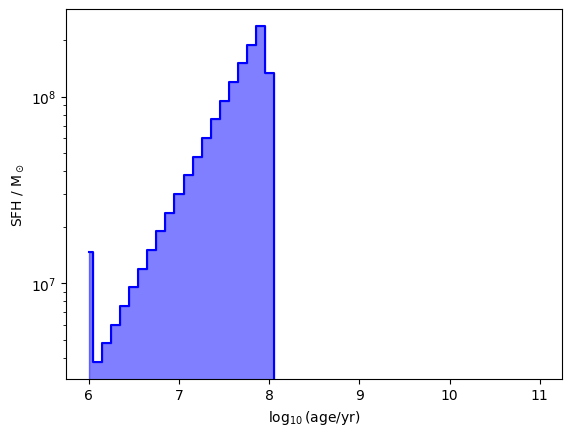

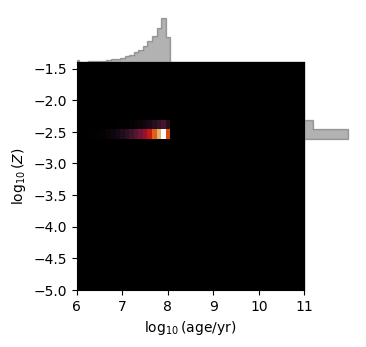

--- Initial mass:
9.11
9.11
--- Surviving mass:
9.00


In [9]:
stars2 = Stars(
    grid.log10ages,
    grid.metallicities,
    sf_hist=sfh,
    metal_dist=metal_dist,
    surviving_mass=10**9 * Msun,
    grid=grid,
    age_offset=900*Myr
)

stars2.plot_sfh()
stars2.plot_sfzh()

print('--- Initial mass:')
print(f'{np.log10(stars2.initial_mass.to("Msun").value):.2f}')
print(f'{np.log10(np.sum(stars2.sf_hist)):.2f}')
print('--- Surviving mass:')
print(f'{np.log10(stars2.calculate_surviving_mass(grid=grid).to("Msun").value):.2f}')

## instantaneous burst

In [10]:
# Create the Stars object
stars = Stars(
    grid.log10ages,
    grid.metallicities,
    sf_hist=100*Myr,
    metal_dist=0.01,
    surviving_mass=10**9 * Msun,
    grid=grid,
)

print('--- Initial mass:')
print(f'{np.log10(stars.initial_mass.to("Msun").value):.2f}')
print(f'{np.log10(np.sum(stars.sf_hist)):.2f}')
print('--- Surviving mass:')
print(f'{np.log10(stars.calculate_surviving_mass(grid=grid).to("Msun").value):.2f}')


--- Initial mass:
9.15
9.15
--- Surviving mass:
9.00
